In [164]:
import yfinance as yf

In [166]:
from datetime import datetime
end =datetime.now()
start = datetime(end.year-20,end.month,end.day)

This code first imports the `datetime` module and captures the current date and time in the variable `end`.
Then, it creates another `datetime` object called `start`, which represents the same month and day but 20 years earlier, using `end.year - 20`.
This ensures that `start` holds the date from two decades ago while keeping the month and day unchanged.
However, since no specific time was set, it defaults to midnight (`00:00:00`). Essentially, this helps track a date exactly 20 years before today.


In [169]:
stock = 'SAIL.NS'
steel_authority = yf.download(stock ,start,end)

[*********************100%***********************]  1 of 1 completed


This code uses `yfinance` to download **Steel Authority of India Ltd (SAIL.NS)** stock data for the past 20 years, storing it in `steel_authority` as a DataFrame.


In [172]:
steel_authority.head()

Price,Close,High,Low,Open,Volume
Ticker,SAIL.NS,SAIL.NS,SAIL.NS,SAIL.NS,SAIL.NS
Date,,,,,
2005-04-19,34.902622,36.438211,34.742665,35.222536,78963055
2005-04-20,35.510456,36.470198,34.262791,36.470198,107264420
2005-04-21,36.182281,36.310248,34.614702,36.054315,61818340
2005-04-22,35.990330,37.046047,35.734398,37.046047,43908500
2005-04-25,35.574436,36.310239,35.318506,35.990325,49623125


In [174]:
steel_authority.shape

(4935, 5)

In [176]:
steel_authority.describe()

Price,Close,High,Low,Open,Volume
Ticker,SAIL.NS,SAIL.NS,SAIL.NS,SAIL.NS,SAIL.NS
count,4935.000000,4935.000000,4935.000000,4935.000000,4.935000e+03
mean,77.296855,78.931715,75.806832,77.463732,2.939965e+07
std,38.079736,38.895198,37.300908,38.208745,2.730266e+07
min,17.534628,18.050353,17.319743,18.050353,0.000000e+00
25%,47.807222,48.843285,46.924853,47.828367,1.170441e+07
50%,67.044174,68.529819,65.780165,67.176131,2.134526e+07
75%,102.604084,104.960227,100.820601,102.689574,3.861597e+07
max,200.610550,204.270661,196.915565,202.109478,3.229646e+08


In [178]:
steel_authority.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4935 entries, 2005-04-19 to 2025-04-17
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, SAIL.NS)   4935 non-null   float64
 1   (High, SAIL.NS)    4935 non-null   float64
 2   (Low, SAIL.NS)     4935 non-null   float64
 3   (Open, SAIL.NS)    4935 non-null   float64
 4   (Volume, SAIL.NS)  4935 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 231.3 KB


In [180]:
steel_authority.isna().sum()

Price   Ticker 
Close   SAIL.NS    0
High    SAIL.NS    0
Low     SAIL.NS    0
Open    SAIL.NS    0
Volume  SAIL.NS    0
dtype: int64

In [182]:
import matplotlib.pyplot as plt
import pandas as pd

Text(0.5, 1.0, 'Closing Price Of Steel Authority')

<Figure size 600x300 with 0 Axes>

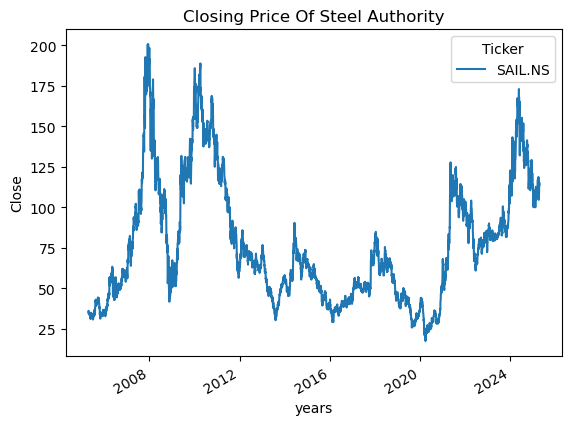

In [184]:
plt.figure(figsize =(6,3))
steel_authority['Close'].plot()
plt.xlabel("years")
plt.ylabel("Close")
plt.title("Closing Price Of Steel Authority")

In [185]:
def plot_graph(figsize, values ,column_name):
    plt.figure(figsize = figsize)
    values.plot()
    plt.xlabel("years")
    plt.ylabel(column_name)
    plt.title(f"{column_name} Of Steel Authority")

In [188]:
steel_authority.columns

MultiIndex([( 'Close', 'SAIL.NS'),
            (  'High', 'SAIL.NS'),
            (   'Low', 'SAIL.NS'),
            (  'Open', 'SAIL.NS'),
            ('Volume', 'SAIL.NS')],
           names=['Price', 'Ticker'])

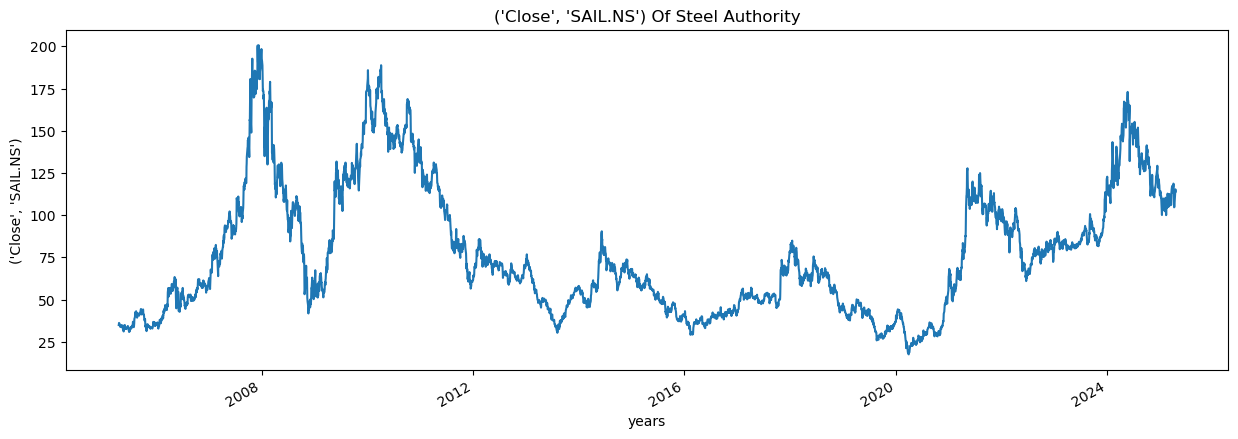

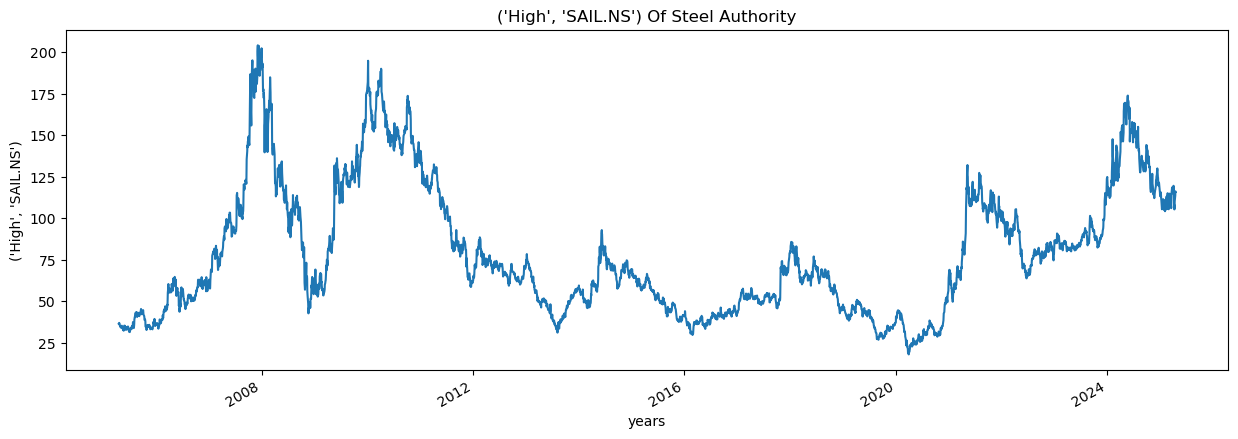

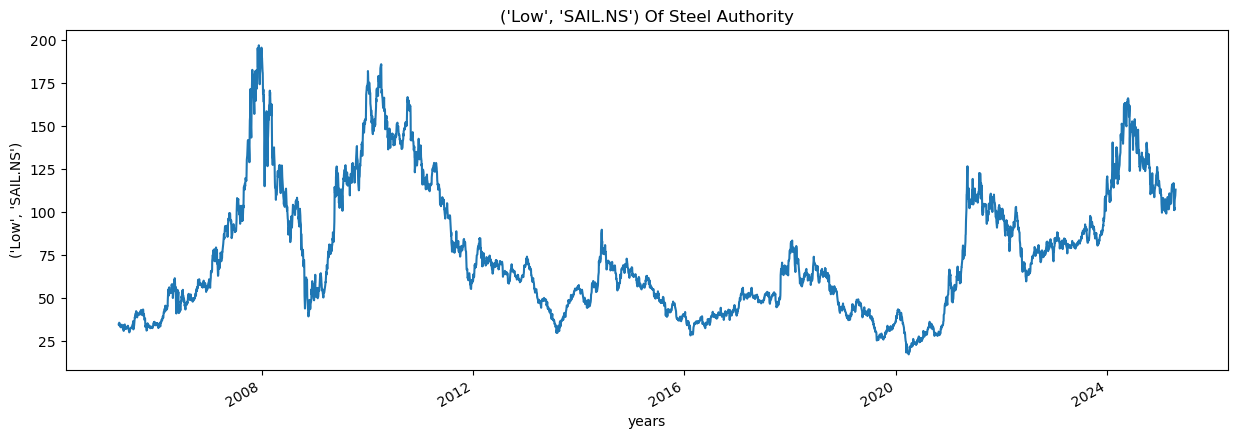

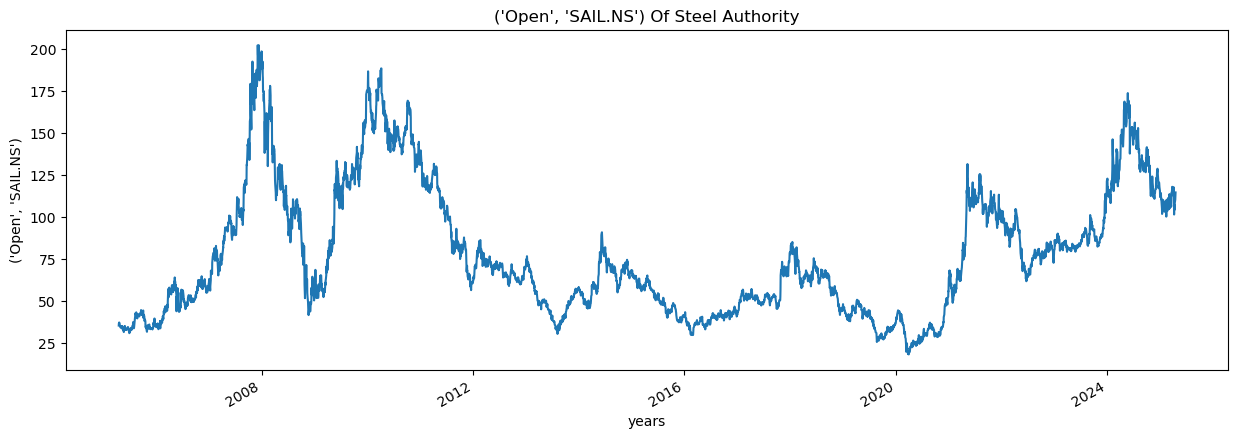

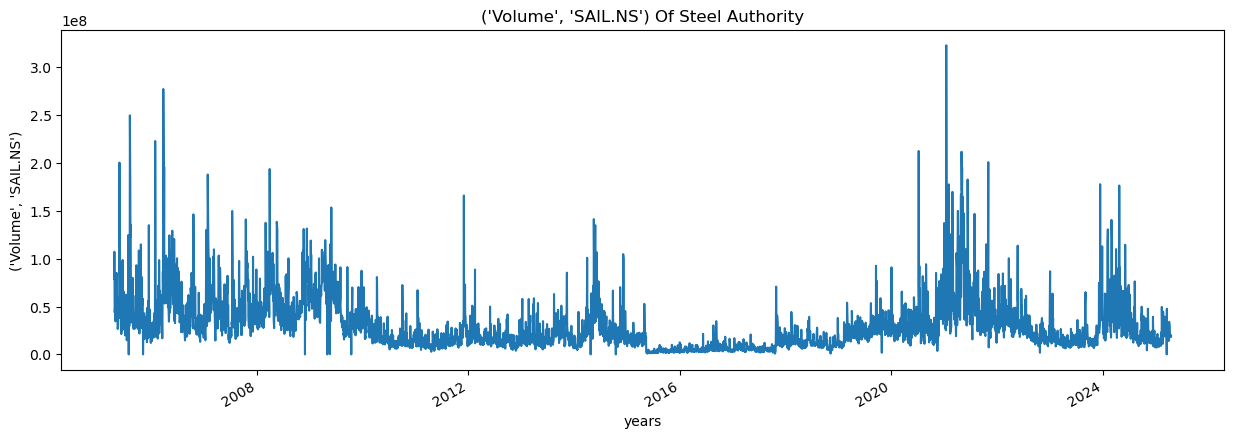

In [190]:
for  column in steel_authority.columns:
    plot_graph((15,5),steel_authority[column],column)

In [191]:
for i in range(2004,2026):
    print(i,list(steel_authority.index.year).count(i))

2004 0
2005 178
2006 247
2007 248
2008 246
2009 243
2010 250
2011 246
2012 245
2013 248
2014 244
2015 246
2016 246
2017 248
2018 246
2019 243
2020 251
2021 248
2022 248
2023 245
2024 246
2025 73


This loop iterates through the years **2004 to 2025**, printing each year along with the count of occurrences in `steel_authority.index.year`, which represents the number of trading days for that year in the stock data.


In [193]:
steel_authority['MA_for_246_days']=steel_authority['Close'].rolling(246).mean()

This creates a new column, **'MA_for_246_days'**, which stores the **246-day moving average** of the stock's closing price, smoothing fluctuations over this period.


In [198]:
steel_authority['MA_for_246_days']

Date
2005-04-19           NaN
2005-04-20           NaN
2005-04-21           NaN
2005-04-22           NaN
2005-04-25           NaN
                 ...    
2025-04-09    129.197062
2025-04-11    129.028180
2025-04-15    128.886316
2025-04-16    128.770938
2025-04-17    128.645070
Name: MA_for_246_days, Length: 4935, dtype: float64

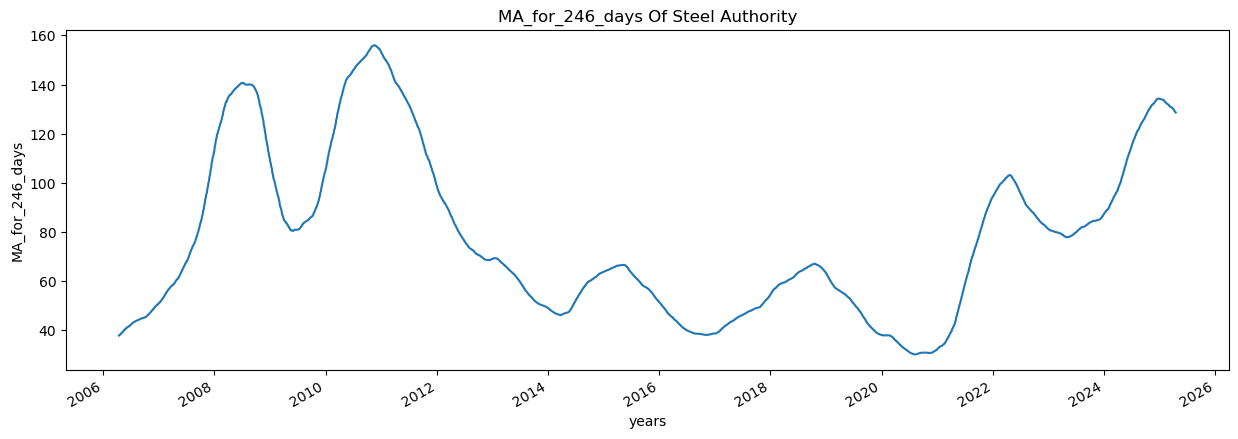

In [200]:
plot_graph((15,5),steel_authority['MA_for_246_days'],'MA_for_246_days')

<Figure size 1500x500 with 0 Axes>

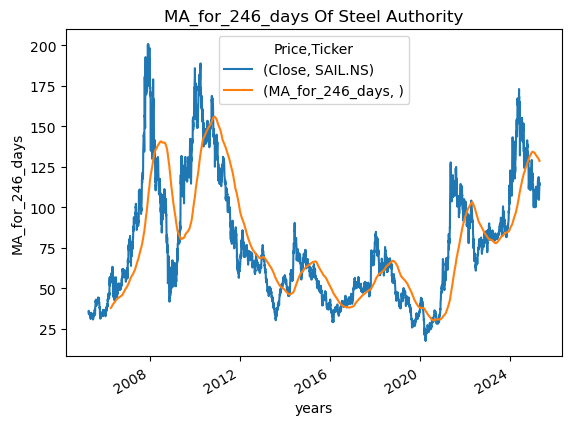

In [201]:
plot_graph((15,5),steel_authority[['Close','MA_for_246_days']],'MA_for_246_days')

<Figure size 1500x500 with 0 Axes>

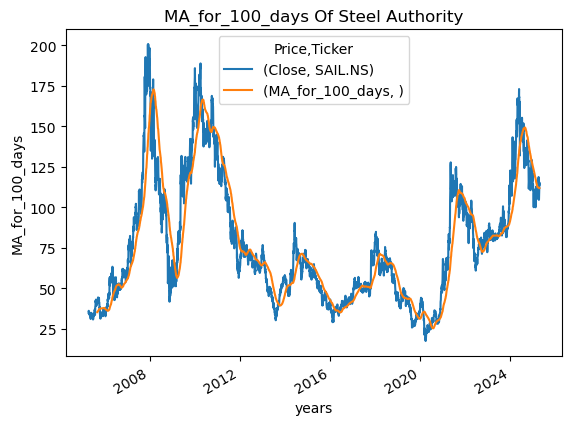

In [203]:
steel_authority['MA_for_100_days']=steel_authority['Close'].rolling(100).mean()
plot_graph((15,5),steel_authority[['Close','MA_for_100_days']],'MA_for_100_days')

<Figure size 1500x500 with 0 Axes>

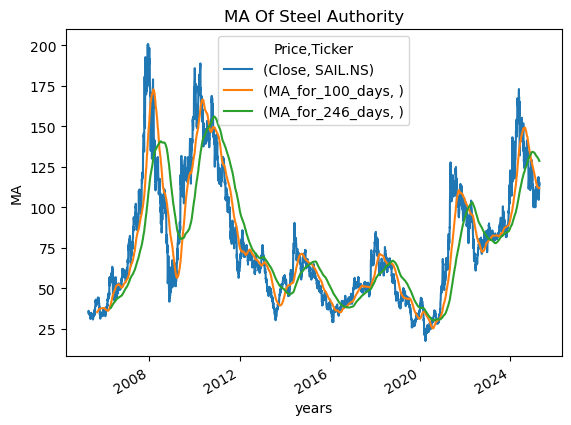

In [205]:
plot_graph((15,5),steel_authority[['Close','MA_for_100_days','MA_for_246_days']],'MA')

In [206]:
steel_authority['percentage_change_cp']=steel_authority['Close'].pct_change()
steel_authority[['Close','percentage_change_cp']].head()

Price,Close,percentage_change_cp
Ticker,SAIL.NS,
Date,,
2005-04-19,34.902622,NaN
2005-04-20,35.510456,0.017415
2005-04-21,36.182281,0.018919
2005-04-22,35.990330,-0.005305
2005-04-25,35.574436,-0.011556


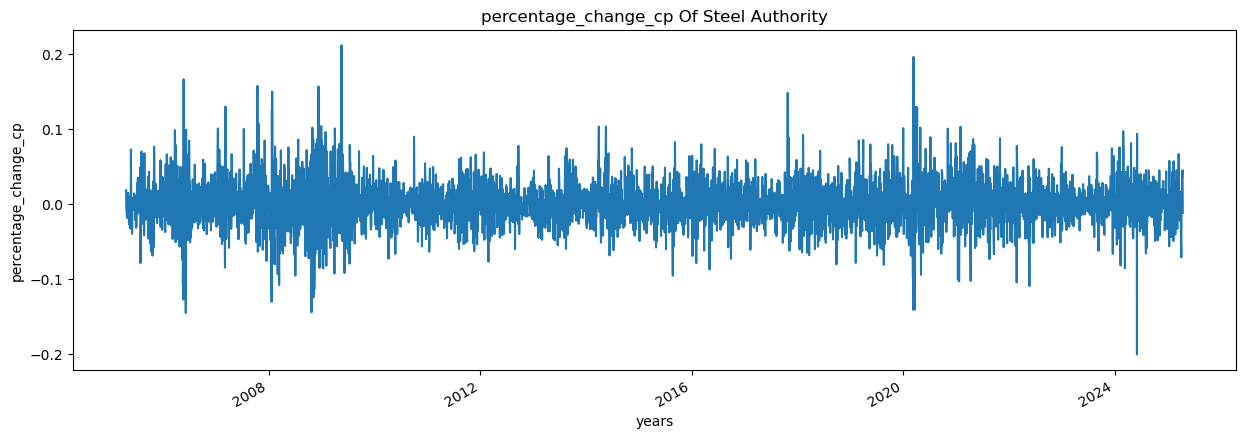

In [208]:
plot_graph((15,5),steel_authority['percentage_change_cp'],'percentage_change_cp')

In [209]:
Close_price= steel_authority[['Close']]

In [212]:
max(Close_price.values),min(Close_price.values)

(array([200.61054993]), array([17.53462791]))

In [215]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(Close_price)
scaled_data

array([[0.09486771],
       [0.09818783],
       [0.10185749],
       ...,
       [0.52281792],
       [0.53401547],
       [0.52669608]])

This code applies **Min-Max scaling** to normalize stock closing prices (`Close_price`) between **0 and 1** using `MinMaxScaler`, ensuring all values fall within this range while preserving relative differences.


In [219]:
len(scaled_data)

4935

In [221]:
x_data =[]
y_data =[]

for i in range(100,len(scaled_data)):
    x_data.append(scaled_data[i-100:i])
    y_data.append(scaled_data[i])

import numpy as np
x_data, y_data =np.array(x_data), np.array(y_data) 

This code prepares data for training a machine learning model. It creates `x_data` as input sequences of the last **100** scaled stock prices and `y_data` as their respective next values. The lists are then converted into NumPy arrays for efficient processing.


In [224]:
x_data[0],y_data[0]

(array([[0.09486771],
        [0.09818783],
        [0.10185749],
        [0.10080901],
        [0.09853731],
        [0.09556668],
        [0.09364448],
        [0.09294553],
        [0.08945065],
        [0.08892642],
        [0.08857691],
        [0.08927598],
        [0.09207181],
        [0.09259606],
        [0.09346976],
        [0.09521717],
        [0.09014966],
        [0.08980019],
        [0.08892642],
        [0.08840215],
        [0.08263564],
        [0.0836841 ],
        [0.08403361],
        [0.08001446],
        [0.07424791],
        [0.0866547 ],
        [0.09294553],
        [0.09294553],
        [0.09346976],
        [0.09381925],
        [0.09504243],
        [0.08752849],
        [0.08281035],
        [0.08315985],
        [0.08420837],
        [0.08420837],
        [0.08281035],
        [0.08438309],
        [0.0836841 ],
        [0.08281035],
        [0.0836841 ],
        [0.08630527],
        [0.08840215],
        [0.08927598],
        [0.08980019],
        [0

In [226]:

int(len(x_data)*0.7)

3384

In [228]:
4939-100-int(len(x_data)*0.7)

1455

In [230]:
splitting_len =int(len(x_data)*0.7)
x_train =x_data [:splitting_len]
y_train =y_data [:splitting_len]

x_test =x_data [splitting_len:]
y_test =y_data [splitting_len:]

In [232]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(3384, 100, 1)
(3384, 1)
(1451, 100, 1)
(1451, 1)


In [234]:
from keras.models import Sequential
from keras.layers import Dense,LSTM

setting up a deep learning model with Keras using `Sequential` for layer stacking, `Dense` for fully connected layers, and `LSTM` for handling sequential data like stock prices. LSTMs are great for time-series forecasting because they capture long-term dependencies. This setup is well-suited for predicting future stock movements based on historical trends.

In [237]:
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape=(x_train.shape[1],1)))
model.add(LSTM(64,return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

C:\Users\vijay\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)




- `Sequential()`: Initializes a model that stacks layers sequentially.
- First `LSTM(128, return_sequences=True)`: Adds an **LSTM layer** with 128 units, returning sequences so the next LSTM layer receives them.
- Second `LSTM(64, return_sequences=False)`: Another **LSTM layer** with 64 units, but without returning sequences, preparing for the dense layers.
- `Dense(25)`: A **fully connected dense layer** with 25 neurons to extract features.
- `Dense(1)`: The final output layer with **1 neuron**, predicting the next value in the time series.



In [240]:
model.compile(optimizer='adam',loss='mean_squared_error')

This **compiles the model**, setting up the optimization and loss functions for training. The **Adam optimizer** adjusts weights efficiently, while **mean squared error (MSE)** measures how far predictions deviate from actual values, making it ideal for regression tasks like stock price forecasting.


In [243]:
model.fit(x_train,y_train,batch_size=1,epochs=2)

Epoch 1/2
3384/3384 ━━━━━━━━━━━━━━━━━━━━ 191s 55ms/step - loss: 0.0021
Epoch 2/2
3384/3384 ━━━━━━━━━━━━━━━━━━━━ 187s 55ms/step - loss: 5.1888e-04


This trains the **LSTM model** using the provided training data. The `batch_size=1` processes one sample at a time, while `epochs=2` runs the training twice over the dataset to adjust model weights for better predictions.


In [244]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [247]:
predictions = model.predict(x_test)

46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step


In [249]:
predictions

array([[0.14955893],
       [0.14155042],
       [0.13867912],
       ...,
       [0.5190103 ],
       [0.5463086 ],
       [0.5550429 ]], dtype=float32)

In [251]:
inv_predictions = scaler.inverse_transform(predictions)
inv_predictions

array([[ 44.915268],
       [ 43.4491  ],
       [ 42.923435],
       ...,
       [112.552925],
       [117.55058 ],
       [119.14963 ]], dtype=float32)

In [253]:
y_test

array([[0.12927898],
       [0.12743043],
       [0.12696833],
       ...,
       [0.52281792],
       [0.53401547],
       [0.52669608]])

In [255]:
inv_y_test = scaler.inverse_transform(y_test)
inv_y_test

array([[ 41.20249557],
       [ 40.86407089],
       [ 40.77947235],
       ...,
       [113.25      ],
       [115.30000305],
       [113.95999908]])

In [257]:
rmse = np.sqrt(np.mean((inv_predictions - inv_y_test)**2))

This calculates the **Root Mean Squared Error (RMSE)**, a common metric for evaluating model accuracy. It first finds the squared differences between the **predictions (`inv_predictions`)** and **actual values (`inv_y_test`)**, computes the mean, then takes the square root to measure the average prediction error in the same units as the original data. Lower RMSE values indicate better model performance.

In [260]:
rmse

3.687081585879051

In [262]:
ploting_data = pd.DataFrame(
    {
        'original_test_data':inv_y_test.reshape(-1),
        'predictions': inv_predictions.reshape(-1)
    },
    index = steel_authority.index[splitting_len+100:]
)
ploting_data.head()

,original_test_data,predictions
Date,,
2019-06-06,41.202496,44.915268
2019-06-07,40.864071,43.449100
2019-06-10,40.779472,42.923435
2019-06-11,41.963932,42.878284
2019-06-12,42.598469,43.988457


<Figure size 1500x600 with 0 Axes>

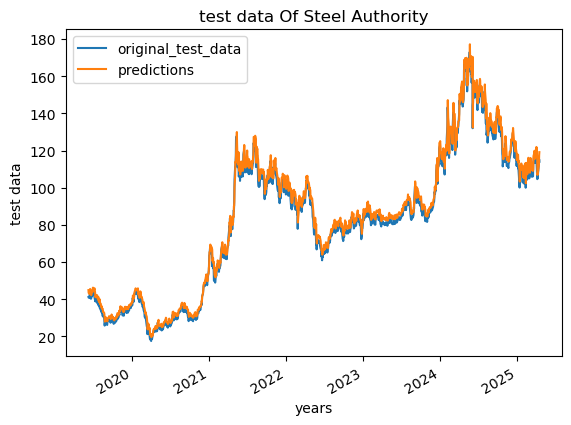

In [264]:
plot_graph((15,6),ploting_data,'test data')

<Figure size 1500x600 with 0 Axes>

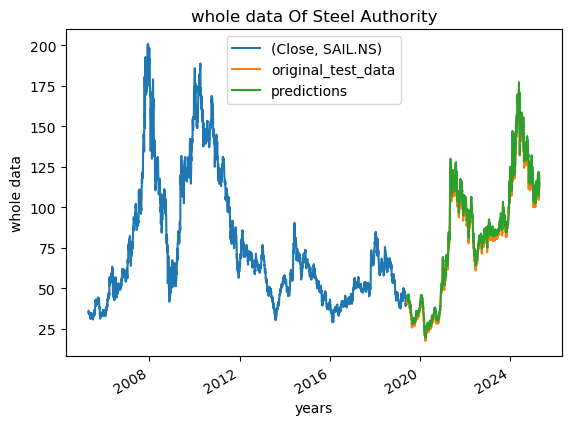

In [266]:
plot_graph((15,6),pd.concat([Close_price[:splitting_len+100],ploting_data],axis=0),'whole data')

In [268]:
model.save("Latest_stock_price_model.keras")